# Task 1 – IB9AU – 2026

**Name**: qizhou lin  
**Task**: Text Sentiment and Topic Analysis on `fakenews.xlsx`

**Key Insights**:
- Applied sentiment analysis to detect emotional tone of spam vs. non-spam messages.
- Used LDA topic modeling to uncover latent themes in text and examine their correlation with spam classification.
- Found that spam messages tend to have slightly lower sentiment scores.
- Some topics are more heavily associated with spam content than others, suggesting thematic clustering.

---


In [7]:
from google.colab import files
uploaded = files.upload()


Saving fakenews.xlsx to fakenews.xlsx


In [9]:
import pandas as pd
file_path = "fakenews.xlsx"
df = pd.read_excel(file_path)
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4912 entries, 0 to 4911
Columns: 427 entries, text to Unnamed: 426
dtypes: float64(1), object(426)
memory usage: 16.0+ MB


,text,label,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 417,Unnamed: 418,Unnamed: 419,Unnamed: 420,Unnamed: 421,Unnamed: 422,Unnamed: 423,Unnamed: 424,Unnamed: 425,Unnamed: 426
0,Get the latest from TODAY Sign up for our news...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2d Conan On The Funeral Trump Will Be Invited...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,It’s safe to say that Instagram Stories has fa...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Much like a certain Amazon goddess with a lass...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,At a time when the perfect outfit is just one ...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df_cleaned = df[['text', 'label']].dropna()
df_cleaned.head()


,text,label
0,Get the latest from TODAY Sign up for our news...,1
1,2d Conan On The Funeral Trump Will Be Invited...,1
2,It’s safe to say that Instagram Stories has fa...,0
3,Much like a certain Amazon goddess with a lass...,0
4,At a time when the perfect outfit is just one ...,0


In [13]:
df_valid_labels = df_cleaned[df_cleaned['label'].apply(lambda x: isinstance(x, int))].copy()
df_valid_labels['label'].value_counts()


,count
label,
0,2925
1,1971


In [14]:
from textblob import TextBlob
df_valid_labels['sentiment'] = df_valid_labels['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_valid_labels.groupby('label')['sentiment'].mean()


,sentiment
label,
0,0.148842
1,0.114848


In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
df_sampled = df_valid_labels.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42))
vectorizer = CountVectorizer(max_df=0.95,min_df=3,stop_words='english')
doc_term_matrix = vectorizer.fit_transform(df_sampled['text'])
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(doc_term_matrix)
doc_topics = lda_model.transform(doc_term_matrix)
df_sampled['dominant_topic'] = doc_topics.argmax(axis=1)


/tmp/ipython-input-1609088722.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_valid_labels.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42))


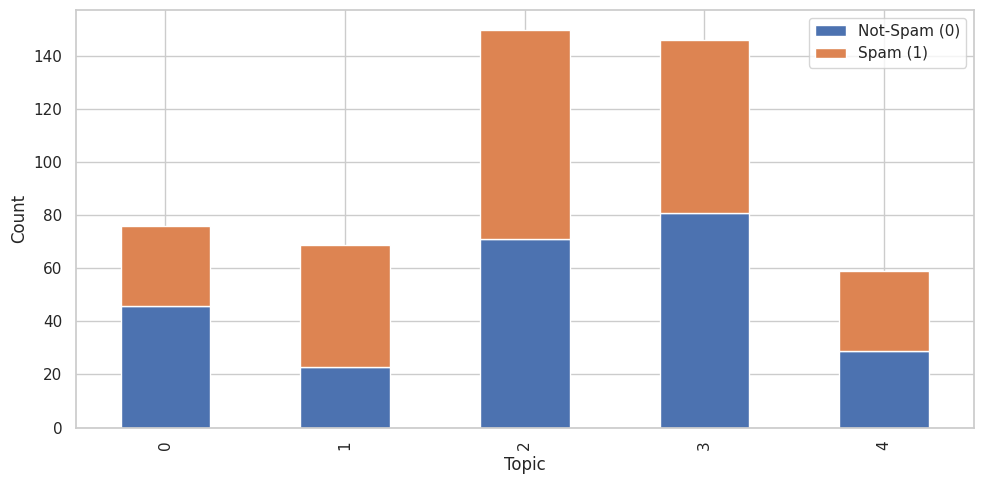

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
topic_label_dist = df_sampled.groupby(['dominant_topic', 'label']).size().unstack(fill_value=0)
sns.set(style="whitegrid")
topic_label_dist.plot(kind="bar", stacked=True, figsize=(10,5))
plt.xlabel("Topic")
plt.ylabel("Count")
plt.legend(["Not-Spam (0)", "Spam (1)"])
plt.tight_layout()
plt.show()


In [17]:
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda_model.components_):
    top_words = [terms[i] for i in topic.argsort()[-10:]]
    print(f"Topic {idx}: {' '.join(top_words)}")


Topic 0: royal film wedding markle winner trump best meghan harry prince
Topic 1: year source said kelly aniston jennifer jolie new pitt brad
Topic 2: old love justin source 2017 just kardashian year instagram time
Topic 3: season going think don know time people just like said
Topic 4: told just love women baby weinstein news people like said
